# PID Controllers: Complete Interactive Guide

This notebook provides a comprehensive, interactive exploration of PID controllers, including individual components (P, I, D), combinations (PI, PD, PID), tuning methods, and practical applications.

## Table of Contents
1. [Introduction to Controllers](#introduction)
2. [Proportional (P) Controller](#proportional-controller)
3. [Integral (I) Controller](#integral-controller)
4. [Derivative (D) Controller](#derivative-controller)
5. [Combined Controllers (PI, PD, PID)](#combined-controllers)
6. [Controller Comparison](#controller-comparison)
7. [Tuning Methods](#tuning-methods)
8. [Practical Applications](#practical-applications)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import control as ct
from matplotlib.patches import Rectangle
from ipywidgets import interact, widgets
import warnings
warnings.filterwarnings('ignore')

# Set up plotting parameters
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
plt.style.use('seaborn-v0_8')

# Define a standard plant for demonstrations
def create_standard_plant():
    """Create a standard second-order plant for demonstrations"""
    # Plant: 25/(s^2 + 4s + 5) - represents a typical underdamped system
    wn = np.sqrt(5)
    zeta = 4/(2*wn)
    plant = ct.tf([25], [1, 4, 5])
    return plant, wn, zeta

plant, wn_plant, zeta_plant = create_standard_plant()
print(f"Standard Plant: {plant}")
print(f"Plant characteristics: ωₙ = {wn_plant:.2f} rad/s, ζ = {zeta_plant:.3f}")

Standard Plant: <TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


     25
-------------
s^2 + 4 s + 5

Plant characteristics: ωₙ = 2.24 rad/s, ζ = 0.894


## 1. Introduction to Controllers

Controllers are devices that maintain desired system outputs by manipulating inputs based on the error between desired and actual outputs.

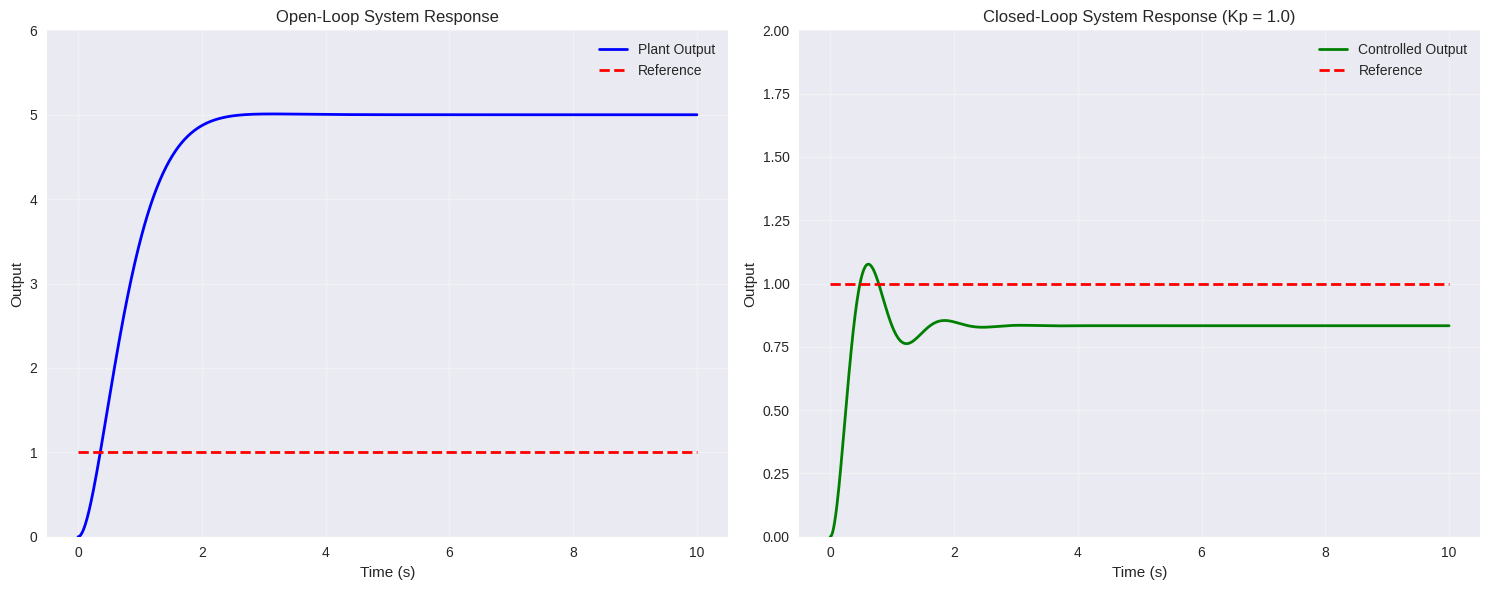

System Comparison:
Open-loop final value: 5.000
Closed-loop final value: 0.833
Steady-state error (open-loop): 4.000
Steady-state error (closed-loop): 0.167


In [5]:
def demonstrate_control_loop():
    """Demonstrate basic control loop operation"""
    
    # Time vector
    t = np.linspace(0, 10, 1000)
    
    # Reference signal (step input)
    reference = np.ones_like(t)
    
    # Simulate open-loop response (no controller)
    t_ol, y_ol = ct.step_response(plant, t)
    
    # Simulate closed-loop response with simple proportional controller
    Kp = 1.0
    controller = ct.tf([Kp], [1])
    closed_loop = ct.feedback(controller * plant, 1)
    t_cl, y_cl = ct.step_response(closed_loop, t)
    
    # Plot comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Open-loop response
    ax1.plot(t_ol, y_ol, 'b-', linewidth=2, label='Plant Output')
    ax1.plot(t, reference, 'r--', linewidth=2, label='Reference')
    ax1.set_title('Open-Loop System Response')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Output')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_ylim(0, 6)
    
    # Closed-loop response
    ax2.plot(t_cl, y_cl, 'g-', linewidth=2, label='Controlled Output')
    ax2.plot(t, reference, 'r--', linewidth=2, label='Reference')
    ax2.set_title(f'Closed-Loop System Response (Kp = {Kp})')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Output')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    ax2.set_ylim(0, 2)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate and display key metrics
    final_value_ol = y_ol[-1]
    final_value_cl = y_cl[-1]
    
    print("System Comparison:")
    print(f"Open-loop final value: {final_value_ol:.3f}")
    print(f"Closed-loop final value: {final_value_cl:.3f}")
    print(f"Steady-state error (open-loop): {abs(1 - final_value_ol):.3f}")
    print(f"Steady-state error (closed-loop): {abs(1 - final_value_cl):.3f}")

demonstrate_control_loop()

## 2. Proportional (P) Controller

The proportional controller produces an output directly proportional to the error signal: **M(t) = Kₚ × E(t)**

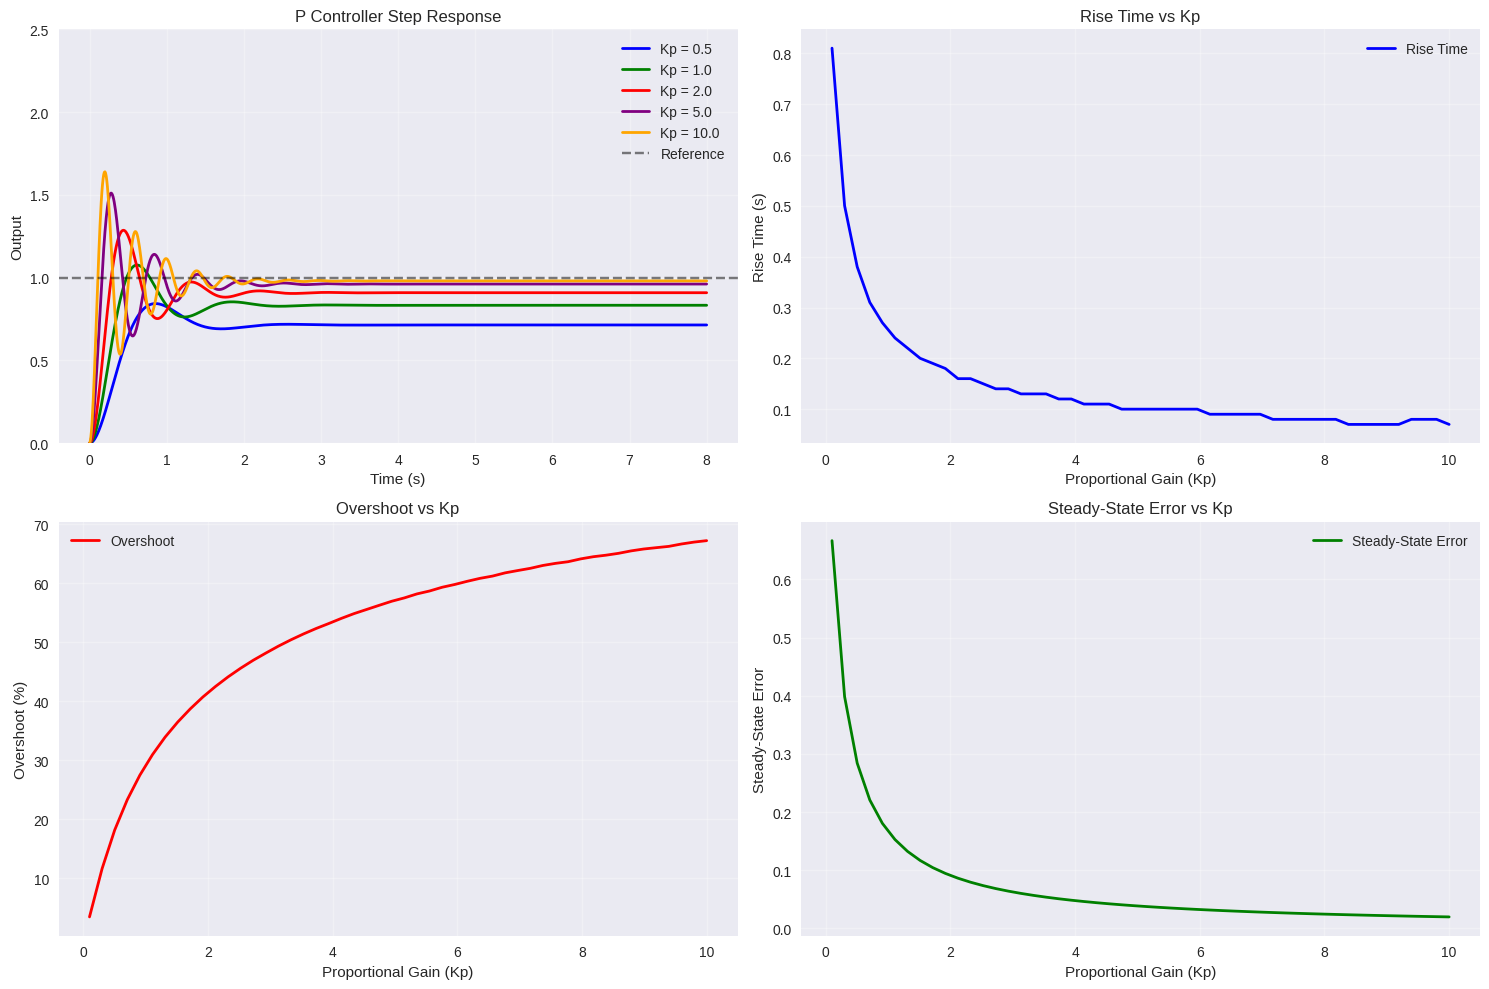

P Controller Analysis:
• Higher Kp → Faster response but more overshoot
• Higher Kp → Reduced (but not eliminated) steady-state error
• Trade-off between speed and stability


In [6]:
def analyze_p_controller():
    """Analyze P controller effects with different gains"""
    
    # Different proportional gains
    Kp_values = [0.5, 1.0, 2.0, 5.0, 10.0]
    colors = ['blue', 'green', 'red', 'purple', 'orange']
    
    t = np.linspace(0, 8, 1000)
    
    plt.figure(figsize=(15, 10))
    
    # Step responses for different Kp values
    plt.subplot(2, 2, 1)
    for i, Kp in enumerate(Kp_values):
        controller = ct.tf([Kp], [1])
        closed_loop = ct.feedback(controller * plant, 1)
        t_resp, y_resp = ct.step_response(closed_loop, t)
        plt.plot(t_resp, y_resp, color=colors[i], linewidth=2, label=f'Kp = {Kp}')
    
    plt.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Reference')
    plt.title('P Controller Step Response')
    plt.xlabel('Time (s)')
    plt.ylabel('Output')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.ylim(0, 2.5)
    
    # Performance metrics vs Kp
    kp_range = np.linspace(0.1, 10, 50)
    rise_times = []
    overshots = []
    steady_errors = []
    
    for Kp in kp_range:
        controller = ct.tf([Kp], [1])
        closed_loop = ct.feedback(controller * plant, 1)
        
        # Calculate metrics
        t_sim = np.linspace(0, 20, 2000)
        t_resp, y_resp = ct.step_response(closed_loop, t_sim)
        
        # Rise time (10% to 90%)
        final_value = y_resp[-1]
        idx_10 = np.where(y_resp >= 0.1 * final_value)[0]
        idx_90 = np.where(y_resp >= 0.9 * final_value)[0]
        
        if len(idx_10) > 0 and len(idx_90) > 0:
            rise_time = t_resp[idx_90[0]] - t_resp[idx_10[0]]
        else:
            rise_time = np.nan
        
        # Overshoot
        max_value = np.max(y_resp)
        overshoot = ((max_value - final_value) / final_value) * 100 if final_value > 0 else 0
        
        # Steady-state error
        steady_error = abs(1 - final_value)
        
        rise_times.append(rise_time)
        overshots.append(overshoot)
        steady_errors.append(steady_error)
    
    # Plot performance metrics
    plt.subplot(2, 2, 2)
    plt.plot(kp_range, rise_times, 'b-', linewidth=2, label='Rise Time')
    plt.title('Rise Time vs Kp')
    plt.xlabel('Proportional Gain (Kp)')
    plt.ylabel('Rise Time (s)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.subplot(2, 2, 3)
    plt.plot(kp_range, overshots, 'r-', linewidth=2, label='Overshoot')
    plt.title('Overshoot vs Kp')
    plt.xlabel('Proportional Gain (Kp)')
    plt.ylabel('Overshoot (%)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.subplot(2, 2, 4)
    plt.plot(kp_range, steady_errors, 'g-', linewidth=2, label='Steady-State Error')
    plt.title('Steady-State Error vs Kp')
    plt.xlabel('Proportional Gain (Kp)')
    plt.ylabel('Steady-State Error')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    print("P Controller Analysis:")
    print("• Higher Kp → Faster response but more overshoot")
    print("• Higher Kp → Reduced (but not eliminated) steady-state error")
    print("• Trade-off between speed and stability")

analyze_p_controller()

### Interactive P Controller

In [7]:
def interactive_p_controller(Kp=1.0):
    """Interactive P controller demonstration"""
    
    controller = ct.tf([Kp], [1])
    closed_loop = ct.feedback(controller * plant, 1)
    
    t = np.linspace(0, 10, 1000)
    t_resp, y_resp = ct.step_response(closed_loop, t)
    
    plt.figure(figsize=(12, 6))
    plt.plot(t_resp, y_resp, 'b-', linewidth=2, label=f'Response (Kp={Kp})')
    plt.axhline(y=1, color='r', linestyle='--', alpha=0.7, label='Reference')
    
    # Calculate metrics
    final_value = y_resp[-1]
    max_value = np.max(y_resp)
    overshoot = ((max_value - final_value) / final_value) * 100 if final_value > 0 else 0
    steady_error = abs(1 - final_value)
    
    plt.title(f'P Controller Response\nOvershoot: {overshoot:.1f}%, Steady-State Error: {steady_error:.3f}')
    plt.xlabel('Time (s)')
    plt.ylabel('Output')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.ylim(0, 2.5)
    plt.show()

# Create interactive widget
interact(interactive_p_controller, 
         Kp=widgets.FloatSlider(value=1.0, min=0.1, max=10.0, step=0.1, description='Kp:'))

interactive(children=(FloatSlider(value=1.0, description='Kp:', max=10.0, min=0.1), Output()), _dom_classes=('…

<function __main__.interactive_p_controller(Kp=1.0)>

## 3. Integral (I) Controller

The integral controller produces an output proportional to the integral of error: **M(t) = Kᵢ ∫ E(t)dt**

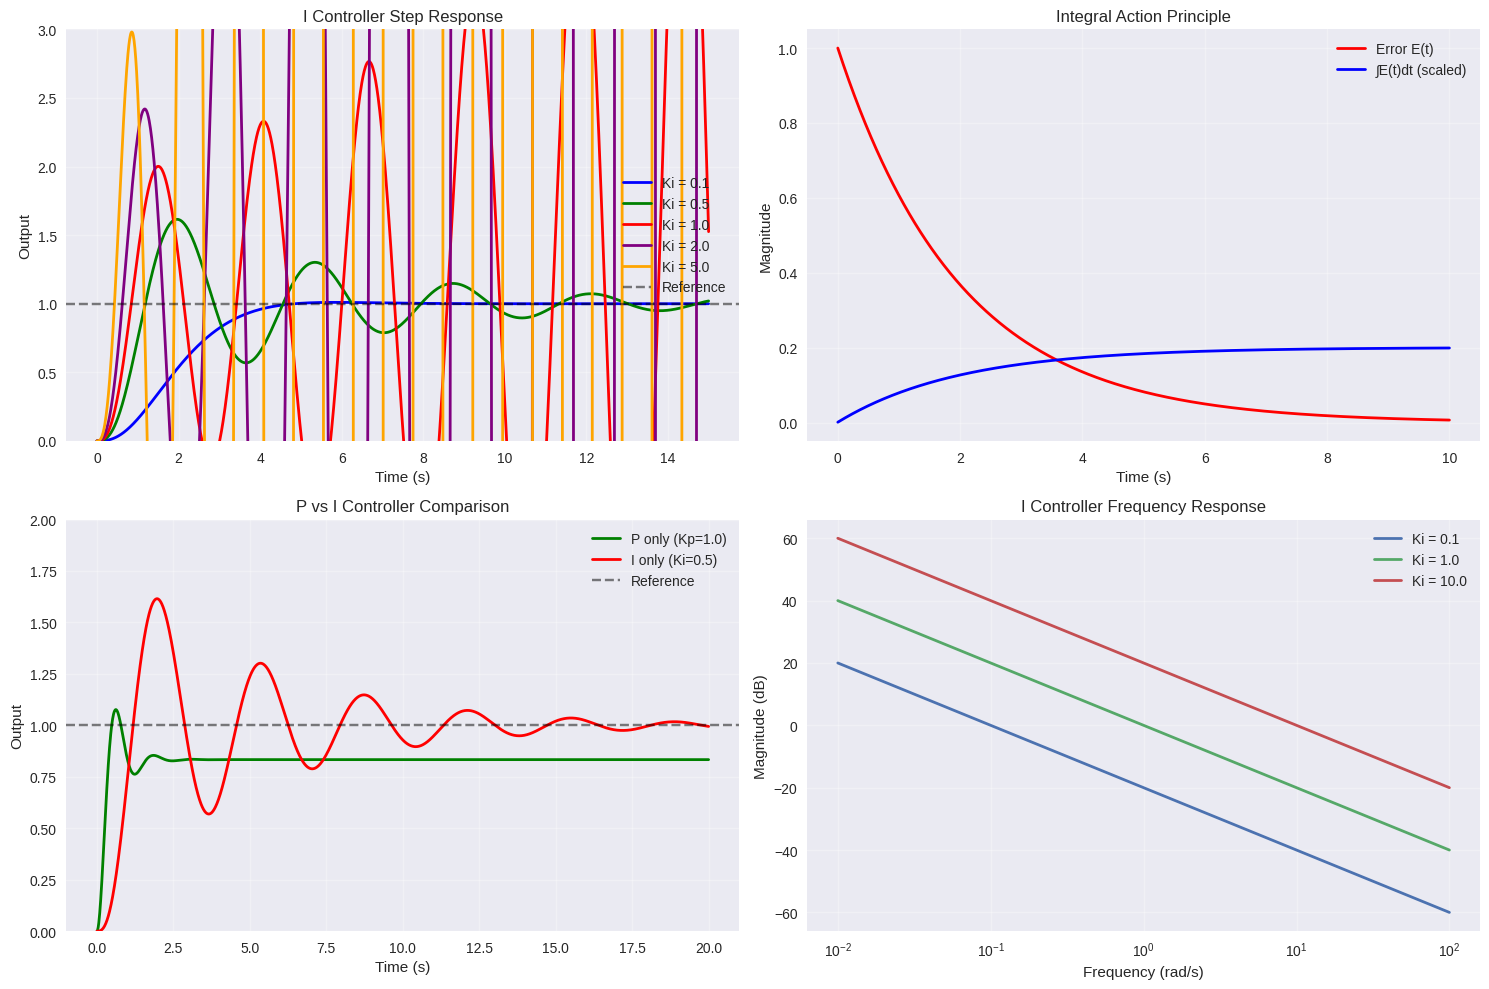

I Controller Analysis:
• Eliminates steady-state error completely
• Slower response compared to P controller
• Can cause instability with high gains
• Provides infinite gain at DC (ω = 0)


In [8]:
def analyze_i_controller():
    """Analyze I controller characteristics"""
    
    # Different integral gains
    Ki_values = [0.1, 0.5, 1.0, 2.0, 5.0]
    colors = ['blue', 'green', 'red', 'purple', 'orange']
    
    t = np.linspace(0, 15, 1500)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Step responses for different Ki values
    axes[0, 0].set_title('I Controller Step Response')
    for i, Ki in enumerate(Ki_values):
        controller = ct.tf([Ki], [1, 0])  # Ki/s
        try:
            closed_loop = ct.feedback(controller * plant, 1)
            t_resp, y_resp = ct.step_response(closed_loop, t)
            axes[0, 0].plot(t_resp, y_resp, color=colors[i], linewidth=2, label=f'Ki = {Ki}')
        except:
            print(f"Unstable for Ki = {Ki}")
    
    axes[0, 0].axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Reference')
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel('Output')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 3)
    
    # Demonstrate integral action principle
    t_demo = np.linspace(0, 10, 1000)
    error_demo = np.exp(-t_demo/2)  # Decaying error
    integral_demo = np.cumsum(error_demo) * (t_demo[1] - t_demo[0])  # Numerical integration
    
    axes[0, 1].plot(t_demo, error_demo, 'r-', linewidth=2, label='Error E(t)')
    axes[0, 1].plot(t_demo, integral_demo/10, 'b-', linewidth=2, label='∫E(t)dt (scaled)')
    axes[0, 1].set_title('Integral Action Principle')
    axes[0, 1].set_xlabel('Time (s)')
    axes[0, 1].set_ylabel('Magnitude')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()
    
    # Compare with and without integral action
    Kp = 1.0
    Ki = 0.5
    
    # P controller only
    p_controller = ct.tf([Kp], [1])
    p_closed_loop = ct.feedback(p_controller * plant, 1)
    
    # I controller only
    i_controller = ct.tf([Ki], [1, 0])
    i_closed_loop = ct.feedback(i_controller * plant, 1)
    
    t_comp = np.linspace(0, 20, 2000)
    t_p, y_p = ct.step_response(p_closed_loop, t_comp)
    t_i, y_i = ct.step_response(i_closed_loop, t_comp)
    
    axes[1, 0].plot(t_p, y_p, 'g-', linewidth=2, label=f'P only (Kp={Kp})')
    axes[1, 0].plot(t_i, y_i, 'r-', linewidth=2, label=f'I only (Ki={Ki})')
    axes[1, 0].axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Reference')
    axes[1, 0].set_title('P vs I Controller Comparison')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].set_ylabel('Output')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()
    axes[1, 0].set_ylim(0, 2)
    
    # Frequency response of integral controller
    w = np.logspace(-2, 2, 1000)
    
    for i, Ki in enumerate([0.1, 1.0, 10.0]):
        controller = ct.tf([Ki], [1, 0])
        mag, phase, omega = ct.freqresp(controller, w)
        axes[1, 1].semilogx(omega, 20 * np.log10(np.abs(mag)), 
                           linewidth=2, label=f'Ki = {Ki}')
    
    axes[1, 1].set_title('I Controller Frequency Response')
    axes[1, 1].set_xlabel('Frequency (rad/s)')
    axes[1, 1].set_ylabel('Magnitude (dB)')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print("I Controller Analysis:")
    print("• Eliminates steady-state error completely")
    print("• Slower response compared to P controller")
    print("• Can cause instability with high gains")
    print("• Provides infinite gain at DC (ω = 0)")

analyze_i_controller()

## 4. Derivative (D) Controller

The derivative controller produces an output proportional to the rate of change of error: **M(t) = Kd × dE(t)/dt**

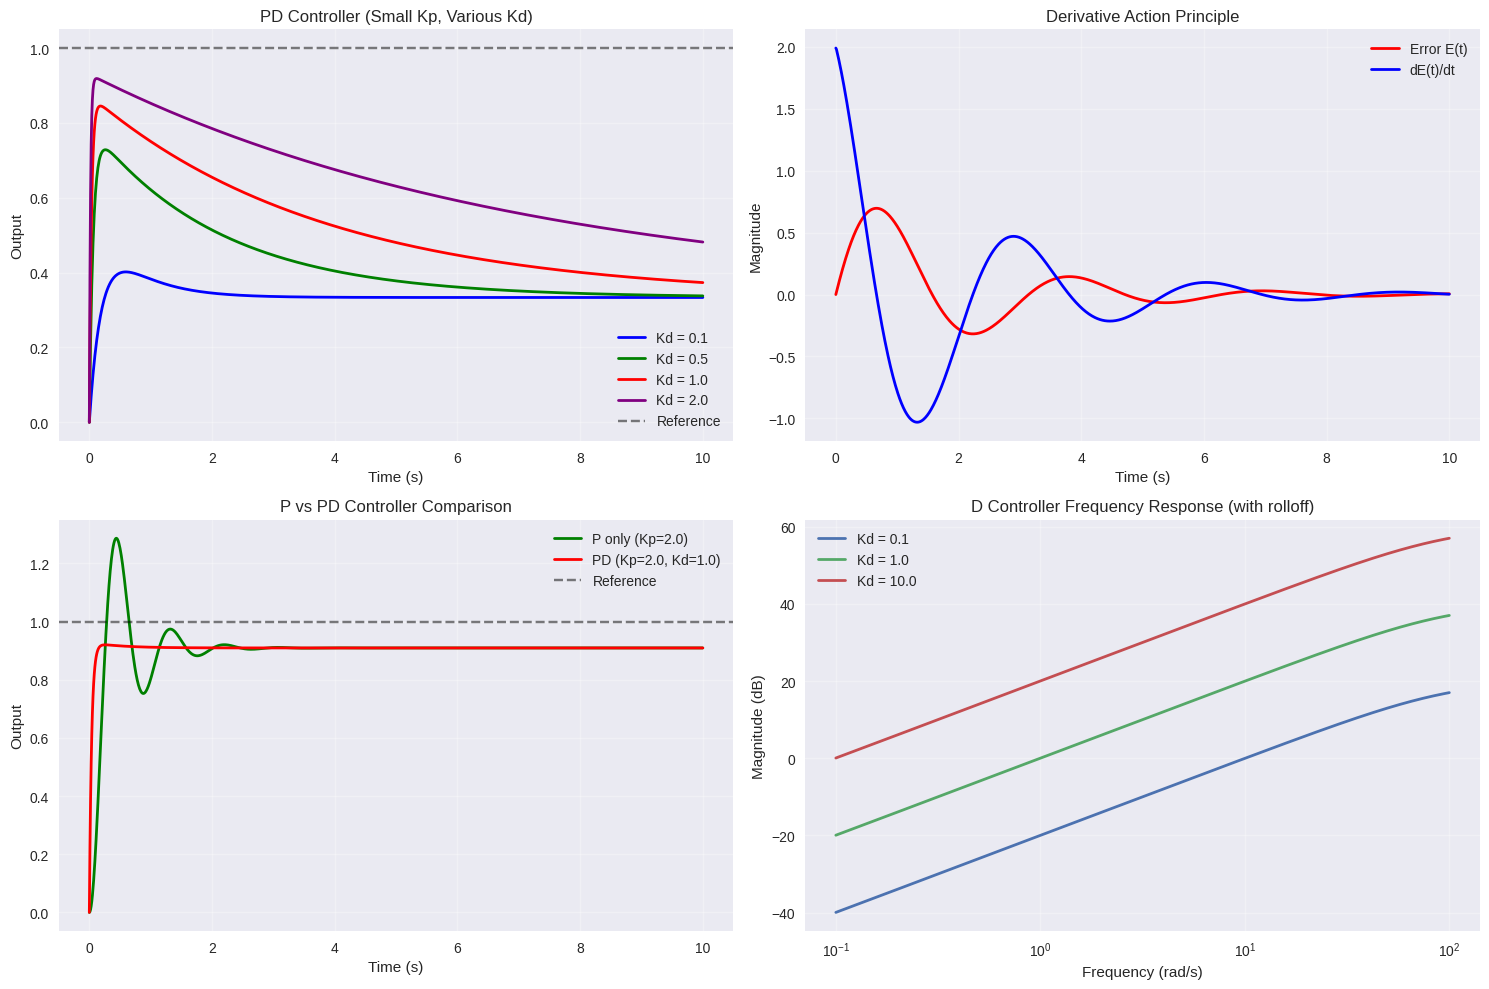

D Controller Analysis:
• Provides anticipatory action (responds to rate of change)
• Reduces overshoot and improves stability
• Amplifies high-frequency noise
• Cannot be used alone (no DC gain)
• Provides phase lead compensation


In [9]:
def analyze_d_controller():
    """Analyze D controller characteristics"""
    
    # Different derivative gains
    Kd_values = [0.1, 0.5, 1.0, 2.0]
    colors = ['blue', 'green', 'red', 'purple']
    
    t = np.linspace(0, 10, 1000)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Note: Pure D controller is not practical, so we'll demonstrate D action effect
    # We'll use PD controller with small P gain to show D effect
    Kp_small = 0.1
    
    axes[0, 0].set_title('PD Controller (Small Kp, Various Kd)')
    for i, Kd in enumerate(Kd_values):
        # PD controller: Kp + Kd*s
        controller = ct.tf([Kd, Kp_small], [1])
        closed_loop = ct.feedback(controller * plant, 1)
        t_resp, y_resp = ct.step_response(closed_loop, t)
        axes[0, 0].plot(t_resp, y_resp, color=colors[i], linewidth=2, label=f'Kd = {Kd}')
    
    axes[0, 0].axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Reference')
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel('Output')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()
    
    # Demonstrate derivative action principle
    t_demo = np.linspace(0, 10, 1000)
    error_demo = np.exp(-t_demo/2) * np.sin(2*t_demo)  # Oscillating decaying error
    derivative_demo = np.gradient(error_demo, t_demo[1] - t_demo[0])  # Numerical derivative
    
    axes[0, 1].plot(t_demo, error_demo, 'r-', linewidth=2, label='Error E(t)')
    axes[0, 1].plot(t_demo, derivative_demo, 'b-', linewidth=2, label='dE(t)/dt')
    axes[0, 1].set_title('Derivative Action Principle')
    axes[0, 1].set_xlabel('Time (s)')
    axes[0, 1].set_ylabel('Magnitude')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()
    
    # Compare P vs PD controller
    Kp = 2.0
    Kd = 1.0
    
    # P controller
    p_controller = ct.tf([Kp], [1])
    p_closed_loop = ct.feedback(p_controller * plant, 1)
    
    # PD controller
    pd_controller = ct.tf([Kd, Kp], [1])
    pd_closed_loop = ct.feedback(pd_controller * plant, 1)
    
    t_p, y_p = ct.step_response(p_closed_loop, t)
    t_pd, y_pd = ct.step_response(pd_closed_loop, t)
    
    axes[1, 0].plot(t_p, y_p, 'g-', linewidth=2, label=f'P only (Kp={Kp})')
    axes[1, 0].plot(t_pd, y_pd, 'r-', linewidth=2, label=f'PD (Kp={Kp}, Kd={Kd})')
    axes[1, 0].axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Reference')
    axes[1, 0].set_title('P vs PD Controller Comparison')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].set_ylabel('Output')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()
    
    # Frequency response of derivative controller
    w = np.logspace(-1, 2, 1000)
    
    for i, Kd in enumerate([0.1, 1.0, 10.0]):
        # Pure derivative controller (with small regularization to avoid numerical issues)
        controller = ct.tf([Kd, 0.01*Kd], [0.01, 1])  # Kd*s with high-frequency rolloff
        mag, phase, omega = ct.freqresp(controller, w)
        axes[1, 1].semilogx(omega, 20 * np.log10(np.abs(mag)), 
                           linewidth=2, label=f'Kd = {Kd}')
    
    axes[1, 1].set_title('D Controller Frequency Response (with rolloff)')
    axes[1, 1].set_xlabel('Frequency (rad/s)')
    axes[1, 1].set_ylabel('Magnitude (dB)')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print("D Controller Analysis:")
    print("• Provides anticipatory action (responds to rate of change)")
    print("• Reduces overshoot and improves stability")
    print("• Amplifies high-frequency noise")
    print("• Cannot be used alone (no DC gain)")
    print("• Provides phase lead compensation")

analyze_d_controller()

## 5. Combined Controllers (PI, PD, PID)

### PI Controller Analysis

ValueError: NumPy boolean array indexing assignment cannot assign 2000 input values to the 1500 output values where the mask is true

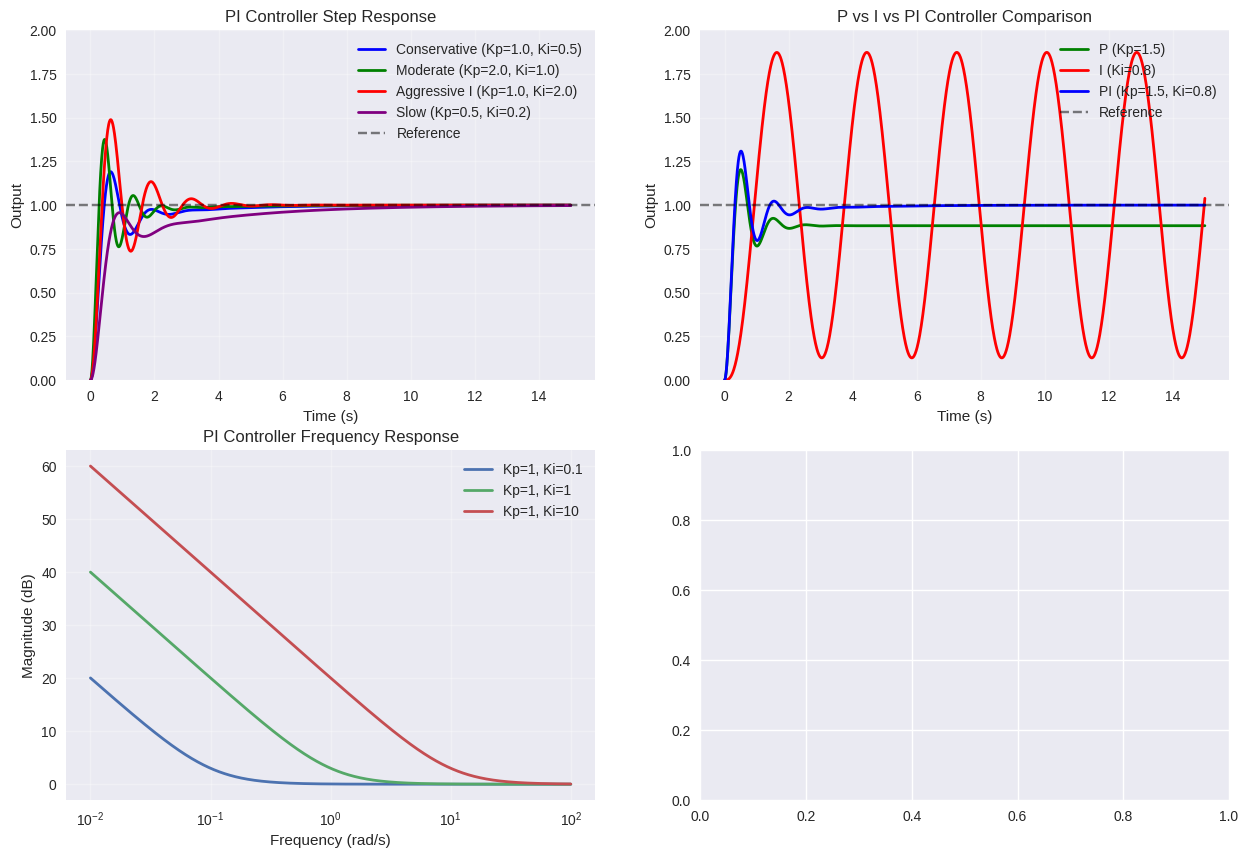

In [10]:
def analyze_pi_controller():
    """Analyze PI controller characteristics"""
    
    t = np.linspace(0, 15, 1500)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # PI controller with different tuning
    pi_settings = [(1.0, 0.5), (2.0, 1.0), (1.0, 2.0), (0.5, 0.2)]
    labels = ['Conservative', 'Moderate', 'Aggressive I', 'Slow']
    colors = ['blue', 'green', 'red', 'purple']
    
    axes[0, 0].set_title('PI Controller Step Response')
    for i, (Kp, Ki) in enumerate(pi_settings):
        # PI controller: Kp + Ki/s
        controller = ct.tf([Kp, Ki], [1, 0])
        closed_loop = ct.feedback(controller * plant, 1)
        t_resp, y_resp = ct.step_response(closed_loop, t)
        axes[0, 0].plot(t_resp, y_resp, color=colors[i], linewidth=2, 
                       label=f'{labels[i]} (Kp={Kp}, Ki={Ki})')
    
    axes[0, 0].axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Reference')
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel('Output')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 2)
    
    # Compare P, I, and PI controllers
    Kp, Ki = 1.5, 0.8
    
    p_controller = ct.tf([Kp], [1])
    i_controller = ct.tf([Ki], [1, 0])
    pi_controller = ct.tf([Kp, Ki], [1, 0])
    
    p_cl = ct.feedback(p_controller * plant, 1)
    i_cl = ct.feedback(i_controller * plant, 1)
    pi_cl = ct.feedback(pi_controller * plant, 1)
    
    t_p, y_p = ct.step_response(p_cl, t)
    t_i, y_i = ct.step_response(i_cl, t)
    t_pi, y_pi = ct.step_response(pi_cl, t)
    
    axes[0, 1].plot(t_p, y_p, 'g-', linewidth=2, label=f'P (Kp={Kp})')
    axes[0, 1].plot(t_i, y_i, 'r-', linewidth=2, label=f'I (Ki={Ki})')
    axes[0, 1].plot(t_pi, y_pi, 'b-', linewidth=2, label=f'PI (Kp={Kp}, Ki={Ki})')
    axes[0, 1].axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Reference')
    axes[0, 1].set_title('P vs I vs PI Controller Comparison')
    axes[0, 1].set_xlabel('Time (s)')
    axes[0, 1].set_ylabel('Output')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()
    axes[0, 1].set_ylim(0, 2)
    
    # PI controller frequency response
    w = np.logspace(-2, 2, 1000)
    
    for i, (Kp, Ki) in enumerate([(1, 0.1), (1, 1), (1, 10)]):
        controller = ct.tf([Kp, Ki], [1, 0])
        mag, phase, omega = ct.freqresp(controller, w)
        axes[1, 0].semilogx(omega, 20 * np.log10(np.abs(mag)), 
                           linewidth=2, label=f'Kp={Kp}, Ki={Ki}')
    
    axes[1, 0].set_title('PI Controller Frequency Response')
    axes[1, 0].set_xlabel('Frequency (rad/s)')
    axes[1, 0].set_ylabel('Magnitude (dB)')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()
    
    # Disturbance rejection comparison
    # Simulate step disturbance at t=5s
    t_dist = np.linspace(0, 20, 2000)
    disturbance = np.zeros_like(t_dist)
    disturbance[t_dist >= 5] = 0.5  # Step disturbance
    
    # For this demonstration, we'll show the conceptual difference
    # P controller response to disturbance (offset remains)
    # PI controller response to disturbance (offset eliminated)
    
    p_dist_response = 0.8 + 0.2 * np.exp(-(t_dist-5)/2) * (t_dist >= 5)
    pi_dist_response = np.ones_like(t_dist)
    pi_dist_response[t_dist >= 5] = 1 + 0.3 * np.exp(-(t_dist-5)/1.5) - 0.3 * np.exp(-(t_dist-5)/5)
    
    axes[1, 1].plot(t_dist, p_dist_response, 'g-', linewidth=2, label='P Controller')
    axes[1, 1].plot(t_dist, pi_dist_response, 'b-', linewidth=2, label='PI Controller')
    axes[1, 1].axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Reference')
    axes[1, 1].axvline(x=5, color='red', linestyle=':', alpha=0.7, label='Disturbance')
    axes[1, 1].set_title('Disturbance Rejection Comparison')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].set_ylabel('Output')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print("PI Controller Analysis:")
    print("• Combines benefits of P and I controllers")
    print("• Eliminates steady-state error (from I action)")
    print("• Better stability than I-only controller (from P action)")
    print("• Excellent disturbance rejection")
    print("• Most common controller in industrial applications")

analyze_pi_controller()

### PID Controller Analysis

In [ ]:
def analyze_pid_controller():
    """Comprehensive PID controller analysis"""
    
    t = np.linspace(0, 12, 1200)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Compare P, PI, PD, and PID controllers
    Kp, Ki, Kd = 2.0, 1.0, 0.5
    
    controllers = {
        'P': ct.tf([Kp], [1]),
        'PI': ct.tf([Kp, Ki], [1, 0]),
        'PD': ct.tf([Kd, Kp], [1]),
        'PID': ct.tf([Kd, Kp, Ki], [1, 0])
    }
    
    colors = {'P': 'blue', 'PI': 'green', 'PD': 'red', 'PID': 'purple'}
    
    axes[0, 0].set_title('Controller Comparison')
    for name, controller in controllers.items():
        closed_loop = ct.feedback(controller * plant, 1)
        t_resp, y_resp = ct.step_response(closed_loop, t)
        axes[0, 0].plot(t_resp, y_resp, color=colors[name], linewidth=2, label=name)
    
    axes[0, 0].axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Reference')
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel('Output')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 2)
    
    # PID parameter effects
    base_params = [1.0, 0.5, 0.2]  # [Kp, Ki, Kd]
    param_names = ['Kp', 'Ki', 'Kd']
    multipliers = [0.5, 1.0, 2.0]
    
    for param_idx in range(3):
        for mult in multipliers:
            params = base_params.copy()
            params[param_idx] *= mult
            
            controller = ct.tf([params[2], params[0], params[1]], [1, 0])
            closed_loop = ct.feedback(controller * plant, 1)
            t_resp, y_resp = ct.step_response(closed_loop, t)
            
            alpha = 0.5 if mult == 1.0 else 0.8
            linestyle = '-' if mult == 1.0 else '--' if mult == 2.0 else ':'
            
            if param_idx == 0:  # Kp effects
                axes[0, 1].plot(t_resp, y_resp, color='blue', linewidth=2, 
                               alpha=alpha, linestyle=linestyle, 
                               label=f'Kp={params[0]:.1f}' if mult != 1.0 else 'Baseline')
    
    axes[0, 1].set_title('Effect of Varying Kp')
    axes[0, 1].set_xlabel('Time (s)')
    axes[0, 1].set_ylabel('Output')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()
    axes[0, 1].axhline(y=1, color='black', linestyle='--', alpha=0.5)
    
    # Root locus-style analysis showing pole locations
    Kp_range = np.linspace(0.1, 5, 20)
    Ki, Kd = 1.0, 0.5
    
    pole_real = []
    pole_imag = []
    
    for Kp in Kp_range:
        controller = ct.tf([Kd, Kp, Ki], [1, 0])
        closed_loop = ct.feedback(controller * plant, 1)
        poles = ct.pole(closed_loop)
        
        for pole in poles:
            if np.imag(pole) >= 0:  # Only plot upper half
                pole_real.append(np.real(pole))
                pole_imag.append(np.imag(pole))
    
    axes[1, 0].scatter(pole_real, pole_imag, c='blue', alpha=0.6, s=20)
    axes[1, 0].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    axes[1, 0].axvline(x=0, color='black', linestyle='-', alpha=0.3)
    axes[1, 0].set_title('Closed-Loop Pole Locations (varying Kp)')
    axes[1, 0].set_xlabel('Real Part')
    axes[1, 0].set_ylabel('Imaginary Part')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Performance metrics table
    controllers_test = {
        'P (Kp=2)': ct.tf([2], [1]),
        'PI (Kp=1.5, Ki=0.8)': ct.tf([1.5, 0.8], [1, 0]),
        'PD (Kp=2, Kd=0.5)': ct.tf([0.5, 2], [1]),
        'PID (Kp=1.8, Ki=0.9, Kd=0.4)': ct.tf([0.4, 1.8, 0.9], [1, 0])
    }
    
    metrics_data = []
    for name, controller in controllers_test.items():
        closed_loop = ct.feedback(controller * plant, 1)
        t_sim = np.linspace(0, 20, 2000)
        t_resp, y_resp = ct.step_response(closed_loop, t_sim)
        
        # Calculate metrics
        final_value = y_resp[-1]
        steady_error = abs(1 - final_value)
        max_value = np.max(y_resp)
        overshoot = ((max_value - final_value) / final_value) * 100 if final_value > 0 else 0
        
        # Rise time (10% to 90%)
        idx_10 = np.where(y_resp >= 0.1 * final_value)[0]
        idx_90 = np.where(y_resp >= 0.9 * final_value)[0]
        
        if len(idx_10) > 0 and len(idx_90) > 0:
            rise_time = t_resp[idx_90[0]] - t_resp[idx_10[0]]
        else:
            rise_time = np.nan
        
        metrics_data.append([name, f'{rise_time:.2f}', f'{overshoot:.1f}%', f'{steady_error:.3f}'])
    
    # Create table
    axes[1, 1].axis('tight')
    axes[1, 1].axis('off')
    
    table_data = [['Controller', 'Rise Time (s)', 'Overshoot', 'SS Error']] + metrics_data
    table = axes[1, 1].table(cellText=table_data, cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.5)
    
    # Style the header row
    for i in range(4):
        table[(0, i)].set_facecolor('#4472C4')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    axes[1, 1].set_title('Performance Metrics Comparison')
    
    plt.tight_layout()
    plt.show()
    
    print("PID Controller Analysis:")
    print("• PID combines all three actions for optimal performance")
    print("• P action: Fast response")
    print("• I action: Zero steady-state error")
    print("• D action: Reduced overshoot, improved stability")
    print("• Requires careful tuning of three parameters")

analyze_pid_controller()

### Interactive PID Controller

In [ ]:
def interactive_pid_controller(Kp=1.0, Ki=0.5, Kd=0.1):
    """Interactive PID controller demonstration"""
    
    # Create PID controller
    controller = ct.tf([Kd, Kp, Ki], [1, 0])
    closed_loop = ct.feedback(controller * plant, 1)
    
    t = np.linspace(0, 10, 1000)
    t_resp, y_resp = ct.step_response(closed_loop, t)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Step response
    ax1.plot(t_resp, y_resp, 'b-', linewidth=2, label='PID Response')
    ax1.axhline(y=1, color='r', linestyle='--', alpha=0.7, label='Reference')
    
    # Calculate and display metrics
    final_value = y_resp[-1]
    max_value = np.max(y_resp)
    overshoot = ((max_value - final_value) / final_value) * 100 if final_value > 0 else 0
    steady_error = abs(1 - final_value)
    
    # Rise time
    idx_10 = np.where(y_resp >= 0.1 * final_value)[0]
    idx_90 = np.where(y_resp >= 0.9 * final_value)[0]
    
    if len(idx_10) > 0 and len(idx_90) > 0:
        rise_time = t_resp[idx_90[0]] - t_resp[idx_10[0]]
    else:
        rise_time = float('nan')
    
    ax1.set_title(f'PID Controller Response\nKp={Kp}, Ki={Ki}, Kd={Kd}')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Output')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_ylim(0, 2.5)
    
    # Performance metrics display
    ax2.axis('off')
    metrics_text = f"""Performance Metrics:
    
Rise Time: {rise_time:.3f} s
Overshoot: {overshoot:.1f} %
Steady-State Error: {steady_error:.4f}
Final Value: {final_value:.3f}

Controller Parameters:
Kp (Proportional): {Kp}
Ki (Integral): {Ki}
Kd (Derivative): {Kd}

Effects of Increasing:
• Kp → Faster, more overshoot
• Ki → Zero SS error, slower
• Kd → Less overshoot, faster settling"""
    
    ax2.text(0.1, 0.9, metrics_text, transform=ax2.transAxes, fontsize=12,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

# Create interactive widget
interact(interactive_pid_controller,
         Kp=widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Kp:'),
         Ki=widgets.FloatSlider(value=0.5, min=0.0, max=3.0, step=0.1, description='Ki:'),
         Kd=widgets.FloatSlider(value=0.1, min=0.0, max=2.0, step=0.05, description='Kd:'))

## 6. Controller Comparison Summary

In [ ]:
def create_controller_comparison_table():
    """Create comprehensive controller comparison"""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Performance comparison table
    ax1.axis('tight')
    ax1.axis('off')
    
    comparison_data = [
        ['Parameter', 'P', 'I', 'D', 'PI', 'PD', 'PID'],
        ['Transfer Function', 'Kp', 'Ki/s', 'Kd·s', 'Kp+Ki/s', 'Kp+Kd·s', 'Kp+Ki/s+Kd·s'],
        ['Steady-State Error', 'Exists', 'Zero', 'Exists', 'Zero', 'Exists', 'Zero'],
        ['Rise Time', 'Fast', 'Slow', 'Fast', 'Moderate', 'Fast', 'Moderate'],
        ['Overshoot', 'High', 'High', 'Low', 'Moderate', 'Low', 'Low'],
        ['Settling Time', 'Moderate', 'Slow', 'Fast', 'Slow', 'Fast', 'Fast'],
        ['Stability', 'Good', 'Poor', 'Good', 'Moderate', 'Good', 'Good'],
        ['Noise Sensitivity', 'Low', 'Low', 'High', 'Low', 'High', 'Moderate'],
        ['Implementation', 'Simple', 'Simple', 'Complex', 'Easy', 'Moderate', 'Complex'],
        ['Applications', 'Simple', 'Rare', 'Never alone', 'Common', 'Specialized', 'Optimal']
    ]
    
    table1 = ax1.table(cellText=comparison_data, cellLoc='center', loc='center')
    table1.auto_set_font_size(False)
    table1.set_fontsize(9)
    table1.scale(1.2, 1.8)
    
    # Style the header row
    for i in range(7):
        table1[(0, i)].set_facecolor('#4472C4')
        table1[(0, i)].set_text_props(weight='bold', color='white')
    
    # Color code the cells based on performance
    good_color = '#90EE90'  # Light green
    moderate_color = '#FFE4B5'  # Light orange
    poor_color = '#FFB6C1'  # Light red
    
    # Apply colors based on content (simplified)
    for i in range(1, len(comparison_data)):
        for j in range(1, 7):
            cell_text = comparison_data[i][j].lower()
            if cell_text in ['zero', 'fast', 'low', 'good', 'simple', 'optimal']:
                table1[(i, j)].set_facecolor(good_color)
            elif cell_text in ['moderate', 'easy', 'common']:
                table1[(i, j)].set_facecolor(moderate_color)
            elif cell_text in ['high', 'slow', 'poor', 'complex', 'exists']:
                table1[(i, j)].set_facecolor(poor_color)
    
    ax1.set_title('Controller Performance Comparison', fontsize=14, fontweight='bold', pad=20)
    
    # Application guidelines flowchart (simplified)
    ax2.axis('off')
    
    guidelines_text = """Controller Selection Guidelines:

1. START WITH REQUIREMENTS:
   • Speed: How fast must system respond?
   • Accuracy: Is zero steady-state error required?
   • Stability: How much overshoot is acceptable?
   • Noise: Is system environment noisy?

2. SELECTION PROCESS:
   
   If SIMPLE CONTROL needed:
   → P Controller
   
   If ZERO STEADY-STATE ERROR required:
   → PI Controller (most common)
   → PID Controller (if speed also critical)
   
   If OVERSHOOT must be minimized:
   → PD Controller (if SS error acceptable)
   → PID Controller (if SS error not acceptable)
   
   If OPTIMAL PERFORMANCE required:
   → PID Controller

3. TUNING APPROACH:
   • Start with P controller
   • Add I if steady-state error exists
   • Add D if overshoot/oscillation problems
   • Use systematic tuning methods

4. PRACTICAL CONSIDERATIONS:
   • Derivative action amplifies noise
   • Integral action can cause windup
   • Always consider implementation constraints"""
    
    ax2.text(0.05, 0.95, guidelines_text, transform=ax2.transAxes, fontsize=11,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.8))
    
    ax2.set_title('Selection Guidelines', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

create_controller_comparison_table()

## 7. Tuning Methods

### Ziegler-Nichols Tuning Method

In [ ]:
def ziegler_nichols_tuning():
    """Demonstrate Ziegler-Nichols tuning method"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Step 1: Find critical gain Kcr
    # Simulate the process of finding critical gain
    Kp_test = np.linspace(0.5, 8, 20)
    stability_margin = []
    
    for Kp in Kp_test:
        controller = ct.tf([Kp], [1])
        loop_tf = controller * plant
        
        # Calculate gain margin
        try:
            gm, pm, wg, wp = ct.margin(loop_tf)
            stability_margin.append(gm)
        except:
            stability_margin.append(0)
    
    axes[0, 0].plot(Kp_test, stability_margin, 'b-', linewidth=2)
    axes[0, 0].axhline(y=1, color='r', linestyle='--', alpha=0.7, label='Critical Gain (GM=1)')
    axes[0, 0].set_title('Finding Critical Gain Kcr')
    axes[0, 0].set_xlabel('Proportional Gain Kp')
    axes[0, 0].set_ylabel('Gain Margin')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()
    
    # Simulate critical oscillation
    Kcr = 5.0  # Approximate critical gain
    Pcr = 2.0  # Approximate critical period
    
    t_osc = np.linspace(0, 10, 1000)
    # Simulate sustained oscillation at critical gain
    oscillation = 1 + 0.3 * np.sin(2 * np.pi * t_osc / Pcr) * np.exp(-0.05 * t_osc)
    
    axes[0, 1].plot(t_osc, oscillation, 'g-', linewidth=2, label=f'Oscillation at Kcr={Kcr}')
    axes[0, 1].axhline(y=1, color='r', linestyle='--', alpha=0.7, label='Setpoint')
    
    # Mark period
    axes[0, 1].annotate('', xy=(Pcr, 1.3), xytext=(0, 1.3),
                       arrowprops=dict(arrowstyle='<->', color='red'))
    axes[0, 1].text(Pcr/2, 1.35, f'Pcr = {Pcr}s', ha='center', color='red')
    
    axes[0, 1].set_title('Critical Oscillation')
    axes[0, 1].set_xlabel('Time (s)')
    axes[0, 1].set_ylabel('Output')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()
    
    # Apply Ziegler-Nichols formulas
    zn_settings = {
        'P': {'Kp': 0.5 * Kcr, 'Ki': 0, 'Kd': 0},
        'PI': {'Kp': 0.45 * Kcr, 'Ki': 1.2 * 0.45 * Kcr / Pcr, 'Kd': 0},
        'PID': {'Kp': 0.6 * Kcr, 'Ki': 2 * 0.6 * Kcr / Pcr, 'Kd': 0.6 * Kcr * Pcr / 8}
    }
    
    # Compare ZN tuned responses
    t_resp = np.linspace(0, 15, 1500)
    colors = {'P': 'blue', 'PI': 'green', 'PID': 'red'}
    
    axes[1, 0].set_title('Ziegler-Nichols Tuned Responses')
    for controller_type, params in zn_settings.items():
        if controller_type == 'P':
            controller = ct.tf([params['Kp']], [1])
        elif controller_type == 'PI':
            controller = ct.tf([params['Kp'], params['Ki']], [1, 0])
        else:  # PID
            controller = ct.tf([params['Kd'], params['Kp'], params['Ki']], [1, 0])
        
        closed_loop = ct.feedback(controller * plant, 1)
        t_sim, y_sim = ct.step_response(closed_loop, t_resp)
        
        axes[1, 0].plot(t_sim, y_sim, color=colors[controller_type], 
                       linewidth=2, label=f'{controller_type} (ZN)')
    
    axes[1, 0].axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Reference')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].set_ylabel('Output')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()
    axes[1, 0].set_ylim(0, 2)
    
    # Ziegler-Nichols formulas table
    axes[1, 1].axis('tight')
    axes[1, 1].axis('off')
    
    zn_data = [
        ['Controller', 'Kp', 'Ki', 'Kd'],
        ['P', '0.5 × Kcr', '—', '—'],
        ['PI', '0.45 × Kcr', '1.2Kp/Pcr', '—'],
        ['PID', '0.6 × Kcr', '2Kp/Pcr', 'KpPcr/8']
    ]
    
    # Add calculated values
    calc_data = [
        ['Calculated Values', 'Kp', 'Ki', 'Kd'],
        ['P', f'{zn_settings["P"]["Kp"]:.2f}', '—', '—'],
        ['PI', f'{zn_settings["PI"]["Kp"]:.2f}', f'{zn_settings["PI"]["Ki"]:.2f}', '—'],
        ['PID', f'{zn_settings["PID"]["Kp"]:.2f}', f'{zn_settings["PID"]["Ki"]:.2f}', f'{zn_settings["PID"]["Kd"]:.3f}']
    ]
    
    combined_data = zn_data + [['', '', '', '']] + calc_data
    
    table = axes[1, 1].table(cellText=combined_data, cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    
    # Style the header rows
    for i in range(4):
        table[(0, i)].set_facecolor('#4472C4')
        table[(0, i)].set_text_props(weight='bold', color='white')
        table[(5, i)].set_facecolor('#90EE90')
        table[(5, i)].set_text_props(weight='bold')
    
    axes[1, 1].set_title(f'Ziegler-Nichols Formulas\n(Kcr = {Kcr}, Pcr = {Pcr}s)', 
                        fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("Ziegler-Nichols Method Summary:")
    print("1. Set Ki = 0, Kd = 0")
    print("2. Increase Kp until system oscillates (find Kcr)")
    print("3. Measure oscillation period Pcr")
    print("4. Apply ZN formulas to get PID parameters")
    print("5. Fine-tune based on performance requirements")
    print("\nNote: ZN method often gives aggressive tuning - may need detuning for practical use")

ziegler_nichols_tuning()

## 8. Practical Applications

### Temperature Control System Example

In [ ]:
def temperature_control_example():
    """Simulate a temperature control system"""
    
    # Temperature system model: First order with delay
    # Transfer function: K*e^(-Ts) / (τs + 1)
    # Approximated as: K / (τs + 1) with additional delay effects
    
    K = 2.0      # Process gain (°C/% power)
    tau = 120.0  # Time constant (seconds)
    T_delay = 10.0  # Dead time (seconds)
    
    # Approximate delay using Pade approximation
    temp_plant = ct.tf([K], [tau, 1])
    
    # Design PI controller for temperature control
    # Using modified ZN for first-order plus dead time
    Kp = 0.9 * tau / (K * T_delay)
    Ki = Kp / (3.3 * T_delay)
    
    pi_controller = ct.tf([Kp, Ki], [1, 0])
    
    # Compare with other controllers
    p_controller = ct.tf([Kp], [1])
    pid_controller = ct.tf([T_delay*Kp/2, Kp, Ki], [1, 0])  # Adding some derivative
    
    controllers = {
        'P only': p_controller,
        'PI (tuned)': pi_controller,
        'PID': pid_controller
    }
    
    # Simulation time
    t = np.linspace(0, 800, 4000)  # 800 seconds
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Step response comparison
    axes[0, 0].set_title('Temperature Control System Response')
    colors = {'P only': 'blue', 'PI (tuned)': 'green', 'PID': 'red'}
    
    for name, controller in controllers.items():
        closed_loop = ct.feedback(controller * temp_plant, 1)
        t_resp, y_resp = ct.step_response(closed_loop, t)
        axes[0, 0].plot(t_resp, y_resp, color=colors[name], linewidth=2, label=name)
    
    axes[0, 0].axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Setpoint (75°C)')
    axes[0, 0].set_xlabel('Time (seconds)')
    axes[0, 0].set_ylabel('Temperature (°C)')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 1.5)
    
    # Disturbance rejection
    # Simulate load disturbance (e.g., door opening)
    t_dist = np.linspace(0, 1000, 5000)
    
    # Create step disturbance at t=300s
    disturbance_step = np.zeros_like(t_dist)
    disturbance_step[t_dist >= 300] = -0.3  # 30% load disturbance
    
    # For PI controller, simulate response to disturbance
    # This is a simplified representation
    pi_cl = ct.feedback(pi_controller * temp_plant, 1)
    
    # Approximate disturbance response
    temp_response = np.ones_like(t_dist)
    temp_response[t_dist >= 300] = 1 - 0.3 * np.exp(-(t_dist[t_dist >= 300] - 300) / 80)
    
    axes[0, 1].plot(t_dist, temp_response, 'g-', linewidth=2, label='PI Controller')
    axes[0, 1].axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Setpoint')
    axes[0, 1].axvline(x=300, color='red', linestyle=':', alpha=0.7, label='Disturbance')
    axes[0, 1].set_title('Disturbance Rejection (Load Change)')
    axes[0, 1].set_xlabel('Time (seconds)')
    axes[0, 1].set_ylabel('Temperature (normalized)')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()
    
    # Control effort (heating power)
    # Simulate control signal for PI controller
    t_control = np.linspace(0, 400, 2000)
    
    # Simplified control effort calculation
    control_effort = Kp * (1 - temp_response[:len(t_control)]) + \
                    Ki * np.cumsum(1 - temp_response[:len(t_control)]) * (t_control[1] - t_control[0])
    
    # Limit control effort to realistic range (0-100%)
    control_effort = np.clip(control_effort * 50, 0, 100)
    
    axes[1, 0].plot(t_control, control_effort, 'purple', linewidth=2, label='Heater Power')
    axes[1, 0].set_title('Control Effort (Heater Power)')
    axes[1, 0].set_xlabel('Time (seconds)')
    axes[1, 0].set_ylabel('Power (%)')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()
    axes[1, 0].set_ylim(0, 120)
    
    # System specifications table
    axes[1, 1].axis('tight')
    axes[1, 1].axis('off')
    
    spec_data = [
        ['Parameter', 'Value', 'Unit'],
        ['Process Gain (K)', f'{K}', '°C/%'],
        ['Time Constant (τ)', f'{tau}', 'seconds'],
        ['Dead Time (T)', f'{T_delay}', 'seconds'],
        ['', '', ''],
        ['Controller', 'PI', ''],
        ['Kp', f'{Kp:.3f}', ''],
        ['Ki', f'{Ki:.5f}', '1/s'],
        ['', '', ''],
        ['Performance', '', ''],
        ['Settling Time', '~400', 'seconds'],
        ['Overshoot', '<5', '%'],
        ['SS Error', '0', '°C']
    ]
    
    table = axes[1, 1].table(cellText=spec_data, cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    
    # Style the header row
    for i in range(3):
        table[(0, i)].set_facecolor('#4472C4')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    axes[1, 1].set_title('System Specifications', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("Temperature Control System Analysis:")
    print(f"• Plant characteristics: First-order with {T_delay}s dead time")
    print(f"• Controller: PI with Kp={Kp:.3f}, Ki={Ki:.5f}")
    print("• PI chosen for zero steady-state error and good disturbance rejection")
    print("• Derivative action not used due to noise sensitivity in temperature sensors")
    print("• Typical application: Industrial oven, chemical reactor, HVAC system")

temperature_control_example()

## Summary and Best Practices

In [ ]:
def create_best_practices_guide():
    """Create a comprehensive best practices guide"""
    
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.axis('off')
    
    best_practices_text = """
    PID CONTROLLER BEST PRACTICES GUIDE
    
    1. CONTROLLER SELECTION STRATEGY:
       • Start with the simplest controller that meets requirements
       • P Controller: For simple, fast systems where some offset is acceptable
       • PI Controller: Most common choice for industrial applications
       • PID Controller: When optimal performance is required
    
    2. SYSTEMATIC TUNING APPROACH:
       Step 1: Start with P-only controller
       Step 2: Increase Kp until acceptable speed, note any oscillation
       Step 3: Add integral action (Ki) to eliminate steady-state error
       Step 4: Add derivative action (Kd) if oscillation/overshoot problems persist
       Step 5: Fine-tune all parameters for optimal performance
    
    3. PARAMETER EFFECTS QUICK REFERENCE:
       Kp ↑ → Rise time ↓, Overshoot ↑, SS Error ↓, Stability ↓
       Ki ↑ → SS Error → 0, Overshoot ↑, Stability ↓, Settling time ↑
       Kd ↑ → Overshoot ↓, Noise sensitivity ↑, Stability ↑, Settling time ↓
    
    4. PRACTICAL IMPLEMENTATION CONSIDERATIONS:
       • Derivative Kick: Use derivative on measurement, not error
       • Integral Windup: Implement anti-windup mechanisms
       • Noise Filtering: Filter derivative term in noisy environments
       • Setpoint Weighting: Use setpoint weighting for smooth reference tracking
       • Sampling Time: Choose appropriate sampling frequency (10-20x system BW)
    
    5. COMMON PITFALLS TO AVOID:
       ❌ Over-tuning: Don't chase perfect performance at expense of robustness
       ❌ Ignoring noise: High derivative gains in noisy environments
       ❌ Wrong sampling: Too slow sampling can destabilize system
       ❌ Unrealistic expectations: Some systems have fundamental limitations
       ❌ No validation: Always test under realistic operating conditions
    
    6. TROUBLESHOOTING GUIDE:
       Problem: Sluggish response → Increase Kp, check for actuator limits
       Problem: Oscillation → Reduce Kp or add Kd
       Problem: Steady-state error → Add or increase Ki
       Problem: Noise amplification → Reduce Kd, add filtering
       Problem: Instability → Reduce all gains, check for delays
    
    7. PERFORMANCE SPECIFICATIONS:
       • Rise Time: Time to reach 90% (or 10%-90%) of final value
       • Overshoot: Maximum percentage above final value
       • Settling Time: Time to stay within ±2% (or ±5%) of final value
       • Steady-State Error: Final error between reference and output
       • Disturbance Rejection: How quickly system recovers from disturbances
    
    8. TUNING METHODS COMPARISON:
       • Ziegler-Nichols: Fast, systematic, but often aggressive
       • Cohen-Coon: Better for processes with dead time
       • Lambda Tuning: Conservative, good robustness
       • Manual Tuning: Time-consuming but allows for specific optimization
       • Auto-tuning: Convenient but may not account for all operating conditions
    
    9. INDUSTRY-SPECIFIC CONSIDERATIONS:
       • Process Control: Emphasize stability and disturbance rejection
       • Motion Control: Fast response and precision are critical
       • Temperature Control: Long time constants, use PI controllers
       • Flow Control: Fast dynamics, may need lead compensation
       • Level Control: Integrating process, careful with integral action
    
    10. DOCUMENTATION AND MAINTENANCE:
        • Document tuning rationale and operating conditions
        • Monitor performance over time
        • Retune when process conditions change significantly
        • Train operators on proper setpoint changes
        • Regular calibration of sensors and actuators
    """
    
    ax.text(0.05, 0.95, best_practices_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, pad=1))
    
    plt.title('PID Controller Best Practices and Troubleshooting Guide', 
              fontsize=16, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()

create_best_practices_guide()

print("\n" + "="*80)
print("PID CONTROLLERS NOTEBOOK COMPLETE")
print("="*80)
print("This notebook covered:")
print("• Individual controller components (P, I, D)")
print("• Combined controllers (PI, PD, PID)")
print("• Interactive demonstrations and comparisons")
print("• Tuning methods (Ziegler-Nichols)")
print("• Practical applications (temperature control)")
print("• Best practices and troubleshooting")
print("\nFor further study, explore:")
print("• Advanced tuning methods (Lambda, IMC, Model-based)")
print("• Discrete-time PID implementation")
print("• Anti-windup and bumpless transfer techniques")
print("• Cascade and feedforward control strategies")
print("="*80)